<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/co2_chain_from_compression_to_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CO₂ chain from compression to pipeline

This notebook develops a reproducible capture-terminal-to-pipeline screen for a
CO₂-rich stream. It is intended for process, transport, and CCS engineers who
know basic thermodynamics and Python but are new to building connected NeqSim
process models.

**Prerequisites:** pressure and temperature, phase equilibrium, compressor
efficiency, Darcy pressure loss, and steady-state mass and energy balances.

**Learning objectives**

After completing the notebook, you can:

1. define CO₂-rich fluids with SRK and Peng–Robinson equations of state;
2. preserve and interpret a direct compression-and-aftercooling calculation;
3. construct a four-stage intercooled NeqSim `ProcessSystem`;
4. connect the conditioned stream to `PipeBeggsAndBrills`;
5. retrieve stage duties, pipeline profiles, and CO₂ diagnostics;
6. validate pressure loss against an independent Darcy–Weisbach screen; and
7. evaluate diameter and throughput scenarios against explicit constraints.

## Preservation checklist

The original placeholder contained four useful example elements:

1. a 96 mol% CO₂, 3 mol% methane, and 1 mol% nitrogen fluid;
2. a 100,000 kg/h stream compressed from 25 to 110 bara;
3. aftercooling to 25 °C followed by an 80 km pipeline screen; and
4. a density flag, arrival-pressure estimate, and compact result table.

All four are retained. The original SRK direct-compression case remains visible
as the legacy baseline. Its constant 0.08 bar/km pipeline approximation is
retained as a labelled comparison, then replaced for engineering use by a
current NeqSim pipe calculation. The placeholder contained no figures, so the
seven technical figures added here do not replace any previous visual.

## 1. Clean Colab setup

The setup installs the current public PyPI package only when NeqSim is absent.
A runtime that already provides NeqSim is left unchanged. Installation output
is intentionally quiet; calculated engineering outputs are retained.

In [1]:
import importlib.metadata
import importlib.util
import json
import math
import platform
import subprocess
import sys


if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
            "-q",
        ]
    )

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from neqsim import jneqsim
from neqsim.thermo import TPflash


runtime_table = pd.DataFrame(
    [
        {
            "Runtime": "NeqSim",
            "Version": importlib.metadata.version("neqsim"),
        },
        {
            "Runtime": "Python",
            "Version": platform.python_version(),
        },
        {
            "Runtime": "Java",
            "Version": str(
                jpype.java.lang.System.getProperty(
                    "java.version"
                )
            ),
        },
    ]
)
display(runtime_table)

,Runtime,Version
0,NeqSim,3.16.0
1,Python,3.12.13
2,Java,17.0.19


## 2. NeqSim classes used in the workflow

`SystemSrkEos` preserves the original property model. `SystemPrEos` is used for
the integrated dense-CO₂ workflow because Peng–Robinson is a common cubic-EOS
engineering choice for CO₂-rich mixtures. Cubic models are screening tools
near the critical region; uncertainty and binary parameters still require
project-specific validation.

Streams carry a cloned thermodynamic state between compressors, coolers, and
the pipeline. `ProcessSystem` executes connected units in dependency order.
`CO2FlowCorrections` supplies CO₂-specific diagnostic factors; it does not
replace the pipeline calculation.

In [2]:
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
Stream = jneqsim.process.equipment.stream.Stream
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
PipeBeggsAndBrills = (
    jneqsim.process.equipment.pipeline.PipeBeggsAndBrills
)
CO2FlowCorrections = (
    jneqsim.process.equipment.pipeline.CO2FlowCorrections
)
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

plt.rcParams.update(
    {
        "figure.dpi": 115,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "font.size": 10,
    }
)

BLUE = "#0072B2"
ORANGE = "#D55E00"
GREEN = "#009E73"
PURPLE = "#CC79A7"

## 3. Engineering basis and units

Pressures are absolute in bara, temperatures are in °C when displayed, mass
flow is in kg/h, power and duty are in kW, distance is in km, and diameter and
roughness are in metres.

Equal pressure ratios reduce the peak discharge temperature of an idealized
intercooled train. For $N$ stages, the stage ratio is

$$
r = \left(\frac{p_{\mathrm{out}}}{p_{\mathrm{in}}}\right)^{1/N}
$$

The example uses four stages, 78% isentropic efficiency, and cooling to 25 °C
after every stage. These are educational assumptions, not equipment ratings.

In [3]:
composition = {
    "CO2": 0.96,
    "methane": 0.03,
    "nitrogen": 0.01,
}

feed_temperature_c = 25.0
feed_pressure_bara = 25.0
pipeline_inlet_pressure_bara = 110.0
mass_flow_kg_per_h = 100000.0
isentropic_efficiency = 0.78
intercooler_temperature_c = 25.0
number_of_stages = 4

pipeline_length_m = 80000.0
pipeline_diameter_m = 0.30
pipe_roughness_m = 1.0e-5
pipeline_increments = 40
minimum_arrival_pressure_bara = 90.0
maximum_velocity_m_per_s = 2.0

stage_ratio = (
    pipeline_inlet_pressure_bara / feed_pressure_bara
) ** (1.0 / number_of_stages)
stage_pressures_bara = [
    feed_pressure_bara * stage_ratio**stage
    for stage in range(1, number_of_stages + 1)
]
stage_pressures_bara[-1] = pipeline_inlet_pressure_bara

input_table = pd.DataFrame(
    [
        {
            "Quantity": "Feed pressure",
            "Value": feed_pressure_bara,
            "Unit": "bara",
        },
        {
            "Quantity": "Pipeline inlet pressure",
            "Value": pipeline_inlet_pressure_bara,
            "Unit": "bara",
        },
        {
            "Quantity": "Mass flow",
            "Value": mass_flow_kg_per_h,
            "Unit": "kg/h",
        },
        {
            "Quantity": "Pipeline length",
            "Value": pipeline_length_m / 1000.0,
            "Unit": "km",
        },
        {
            "Quantity": "Pipeline inside diameter",
            "Value": pipeline_diameter_m,
            "Unit": "m",
        },
    ]
)
display(input_table)
print(f"Equal stage pressure ratio: {stage_ratio:.6f} [-]")

Equal stage pressure ratio: 1.448315 [-]


,Quantity,Value,Unit
0,Feed pressure,25.0,bara
1,Pipeline inlet pressure,110.0,bara
2,Mass flow,100000.0,kg/h
3,Pipeline length,80.0,km
4,Pipeline inside diameter,0.3,m


The composition is synthetic and public. It represents a high-purity captured
stream with non-condensable methane and nitrogen impurities. Real CCS design
must also consider water, oxygen, sulfur species, hydrogen, carbon monoxide,
and impurity specifications because they affect phase behavior, corrosion,
metering, and transport capacity.

In [4]:
composition_sum = sum(composition.values())
composition_table = pd.DataFrame(
    [
        {
            "Component": component,
            "Mole fraction [-]": mole_fraction,
            "Mole percent [mol%]": 100.0 * mole_fraction,
        }
        for component, mole_fraction in composition.items()
    ]
)
display(composition_table)
print(f"Composition sum: {composition_sum:.12f} [-]")

Composition sum: 1.000000000000 [-]


,Component,Mole fraction [-],Mole percent [mol%]
0,CO2,0.96,96.0
1,methane,0.03,3.0
2,nitrogen,0.01,1.0


## 4. Reusable fluid factory

A fresh fluid is created for every independent scenario. This prevents hidden
state from prior flashes or process runs. `setMultiPhaseCheck(True)` allows a
state to reveal phase splitting instead of assuming one phase.

In [5]:
def make_co2_fluid(
    temperature_c,
    pressure_bara,
    model_name="pr",
):
    if model_name == "srk":
        fluid = SystemSrkEos(
            273.15 + temperature_c,
            pressure_bara,
        )
    elif model_name == "pr":
        fluid = SystemPrEos(
            273.15 + temperature_c,
            pressure_bara,
        )
    else:
        raise ValueError(
            f"Unsupported model: {model_name}"
        )

    for component, mole_fraction in composition.items():
        fluid.addComponent(
            component,
            mole_fraction,
        )

    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    TPflash(fluid)
    fluid.initProperties()
    return fluid

The original notebook used SRK. The table below preserves that state and adds
PR at the same conditions so the model choice is visible rather than hidden.
The feed is gas-like at 25 bara and 25 °C; after compression and cooling the
same composition becomes much denser.

In [6]:
feed_state_rows = []

for model_name in ["srk", "pr"]:
    model_fluid = make_co2_fluid(
        feed_temperature_c,
        feed_pressure_bara,
        model_name,
    )
    feed_state_rows.append(
        {
            "Model": model_name.upper(),
            "Pressure [bara]": model_fluid.getPressure(
                "bara"
            ),
            "Temperature [°C]": model_fluid.getTemperature(
                "C"
            ),
            "Phases [-]": model_fluid.getNumberOfPhases(),
            "Density [kg/m³]": model_fluid.getDensity(
                "kg/m3"
            ),
            "Z-factor [-]": model_fluid.getZ(),
        }
    )

feed_state_table = pd.DataFrame(feed_state_rows)
display(feed_state_table)

,Model,Pressure [bara],Temperature [°C],Phases [-],Density [kg/m³],Z-factor [-]
0,SRK,25.0,25.0,1,49.972514,0.871251
1,PR,25.0,25.0,1,50.401273,0.858609


## 5. Preserve the direct compression example

The original feed, compressor, cooler, flow, discharge pressure, and aftercooler
temperature are retained in `run_single_stage_case`. Compressor shaft power is
calculated by NeqSim from the inlet state, outlet pressure, and isentropic
efficiency. The thermodynamic definition is

$$
\eta_s = \frac{h_{\mathrm{out,s}} - h_{\mathrm{in}}}
{h_{\mathrm{out}} - h_{\mathrm{in}}}
$$

where $h$ is specific enthalpy in J/kg and the subscript $s$ denotes the
isentropic outlet. The cooler then returns the stream to 25 °C.

In [7]:
def run_single_stage_case(model_name):
    fluid = make_co2_fluid(
        feed_temperature_c,
        feed_pressure_bara,
        model_name,
    )
    feed = Stream(
        f"{model_name.upper()} direct feed",
        fluid,
    )
    feed.setFlowRate(
        mass_flow_kg_per_h,
        "kg/hr",
    )
    compressor = Compressor(
        f"{model_name.upper()} direct compressor",
        feed,
    )
    compressor.setOutletPressure(
        pipeline_inlet_pressure_bara,
        "bara",
    )
    compressor.setIsentropicEfficiency(
        isentropic_efficiency
    )
    cooler = Cooler(
        f"{model_name.upper()} direct aftercooler",
        compressor.getOutletStream(),
    )
    cooler.setOutTemperature(
        intercooler_temperature_c,
        "C",
    )
    process = ProcessSystem()

    for unit in [feed, compressor, cooler]:
        process.add(unit)

    process.run()
    outlet_fluid = cooler.getOutletStream().getFluid()
    outlet_fluid.initProperties()
    return {
        "process": process,
        "feed": feed,
        "compressor": compressor,
        "cooler": cooler,
        "outlet_fluid": outlet_fluid,
    }

In [8]:
legacy_srk_case = run_single_stage_case("srk")
direct_pr_case = run_single_stage_case("pr")

direct_case_rows = []

for model_name, case in [
    ("SRK legacy", legacy_srk_case),
    ("PR comparison", direct_pr_case),
]:
    compressor = case["compressor"]
    outlet_fluid = case["outlet_fluid"]
    direct_case_rows.append(
        {
            "Case": model_name,
            "Power [kW]": compressor.getPower("kW"),
            "Discharge temperature [°C]": (
                compressor.getOutletStream().getTemperature(
                    "C"
                )
            ),
            "Aftercooler temperature [°C]": (
                outlet_fluid.getTemperature("C")
            ),
            "Aftercooler density [kg/m³]": (
                outlet_fluid.getDensity("kg/m3")
            ),
            "Aftercooler phases [-]": (
                outlet_fluid.getNumberOfPhases()
            ),
        }
    )

direct_case_table = pd.DataFrame(direct_case_rows)
display(direct_case_table)

,Case,Power [kW],Discharge temperature [°C],Aftercooler temperature [°C],Aftercooler density [kg/m³],Aftercooler phases [-]
0,SRK legacy,3183.178246,171.812956,25.0,696.275856,1
1,PR comparison,3110.052914,171.928998,25.0,710.083512,1


Direct compression is useful as a transparent baseline, but its high discharge
temperature and power show why industrial CO₂ systems normally use staging and
intercooling. The next section keeps the same boundary conditions while making
the process composable.

## 6. Four-stage intercooled process and connected pipeline

Each compressor receives the previous cooler outlet. The final cooler connects
directly to the pipeline, so composition, flow, enthalpy, pressure, and
temperature propagate through NeqSim objects without manual copying.

The base pipeline is horizontal and isothermal at 25 °C. This isolates hydraulic
behavior for teaching. A design model would replace that assumption with seabed
temperature, insulation, heat transfer, elevation, transient operation, and
fracture-control requirements.

In [9]:
def build_integrated_chain(
    flow_rate_kg_per_h=mass_flow_kg_per_h,
    diameter_m=pipeline_diameter_m,
):
    fluid = make_co2_fluid(
        feed_temperature_c,
        feed_pressure_bara,
        "pr",
    )
    feed = Stream("CO2 capture-terminal feed", fluid)
    feed.setFlowRate(
        flow_rate_kg_per_h,
        "kg/hr",
    )
    units = [feed]
    compressors = []
    coolers = []
    upstream_stream = feed

    for stage_number, pressure_bara in enumerate(
        stage_pressures_bara,
        start=1,
    ):
        compressor = Compressor(
            f"CO2 compressor stage {stage_number}",
            upstream_stream,
        )
        compressor.setOutletPressure(
            pressure_bara,
            "bara",
        )
        compressor.setIsentropicEfficiency(
            isentropic_efficiency
        )
        cooler = Cooler(
            f"Intercooler stage {stage_number}",
            compressor.getOutletStream(),
        )
        cooler.setOutTemperature(
            intercooler_temperature_c,
            "C",
        )
        units.extend([compressor, cooler])
        compressors.append(compressor)
        coolers.append(cooler)
        upstream_stream = cooler.getOutletStream()

    pipeline = PipeBeggsAndBrills(
        "CO2 export pipeline",
        upstream_stream,
    )
    pipeline.setLength(pipeline_length_m)
    pipeline.setElevation(0.0)
    pipeline.setDiameter(diameter_m)
    pipeline.setPipeWallRoughness(pipe_roughness_m)
    pipeline.setNumberOfIncrements(
        pipeline_increments
    )
    pipeline.setRunIsothermal(True)
    units.append(pipeline)

    process = ProcessSystem()

    for unit in units:
        process.add(unit)

    return {
        "process": process,
        "feed": feed,
        "compressors": compressors,
        "coolers": coolers,
        "pipeline": pipeline,
    }

In [10]:
integrated_chain = build_integrated_chain()
integrated_chain["process"].run()

stage_rows = []

for stage_number, (compressor, cooler) in enumerate(
    zip(
        integrated_chain["compressors"],
        integrated_chain["coolers"],
    ),
    start=1,
):
    inlet_fluid = compressor.getInletStream().getFluid()
    compressor_outlet = (
        compressor.getOutletStream().getFluid()
    )
    cooler_outlet = cooler.getOutletStream().getFluid()
    compressor_residual_w = (
        compressor.getPower("W")
        - (
            compressor_outlet.getEnthalpy()
            - inlet_fluid.getEnthalpy()
        )
    )
    cooler_residual_w = (
        cooler_outlet.getEnthalpy()
        - compressor_outlet.getEnthalpy()
        - cooler.getDuty()
    )
    stage_rows.append(
        {
            "Stage [-]": stage_number,
            "Inlet pressure [bara]": (
                inlet_fluid.getPressure("bara")
            ),
            "Outlet pressure [bara]": (
                compressor_outlet.getPressure("bara")
            ),
            "Discharge temperature [°C]": (
                compressor_outlet.getTemperature("C")
            ),
            "Aftercooler temperature [°C]": (
                cooler_outlet.getTemperature("C")
            ),
            "Power [kW]": compressor.getPower("kW"),
            "Cooling removed [kW]": (
                -cooler.getDuty() / 1000.0
            ),
            "Compressor residual [W]": (
                compressor_residual_w
            ),
            "Cooler residual [W]": cooler_residual_w,
        }
    )

stage_table = pd.DataFrame(stage_rows)
display(stage_table)

,Stage [-],Inlet pressure [bara],Outlet pressure [bara],Discharge temperature [°C],Aftercooler temperature [°C],Power [kW],Cooling removed [kW],Compressor residual [W],Cooler residual [W]
0,1,25.000000,36.207887,58.807487,25.0,680.278124,1066.699570,0.0,0.0
1,2,36.207887,52.440442,58.989098,25.0,624.307339,1329.678907,0.0,0.0
2,3,52.440442,75.950304,58.050593,25.0,530.572909,4374.414189,0.0,0.0
3,4,75.950304,110.000000,35.446407,25.0,204.661618,1117.922972,0.0,0.0


The final stage requires less shaft power because the stream is already dense
before reaching 110 bara. This is a real-fluid result, not a constant-$k$
ideal-gas calculation. Near-critical properties make repeated cooling and
model selection especially important.

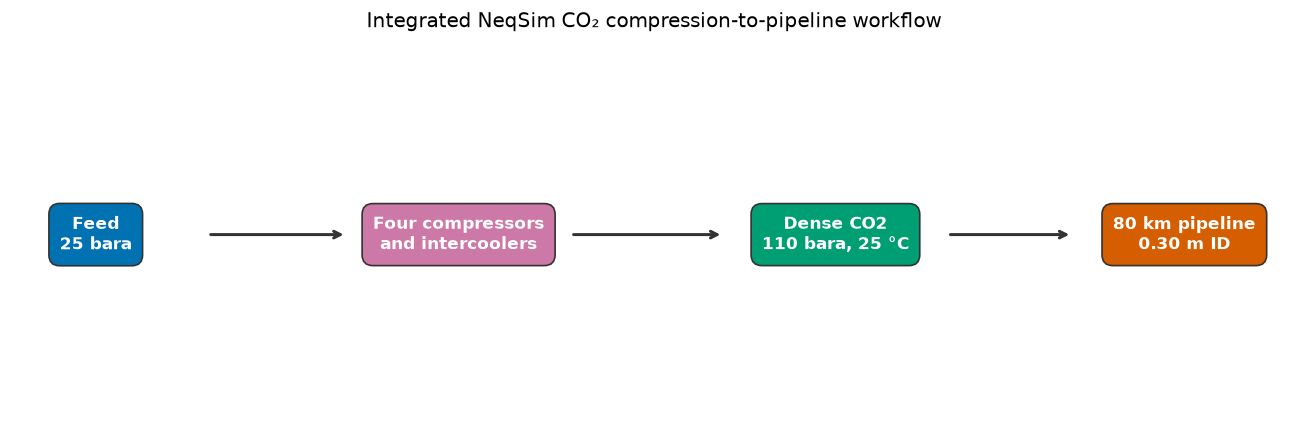

In [11]:
figure, axis = plt.subplots(
    figsize=(11.0, 3.8)
)
node_positions = [
    ("Feed\n25 bara", 0.06, BLUE),
    ("Four compressors\nand intercoolers", 0.32, PURPLE),
    ("Dense CO2\n110 bara, 25 °C", 0.59, GREEN),
    ("80 km pipeline\n0.30 m ID", 0.84, ORANGE),
]

for label, x_position, color in node_positions:
    axis.text(
        x_position,
        0.5,
        label,
        ha="center",
        va="center",
        color="white",
        weight="bold",
        bbox={
            "boxstyle": "round,pad=0.65",
            "facecolor": color,
            "edgecolor": "#333333",
        },
    )

for left_node, right_node in zip(
    node_positions[:-1],
    node_positions[1:],
):
    axis.annotate(
        "",
        xy=(right_node[1] - 0.08, 0.5),
        xytext=(left_node[1] + 0.08, 0.5),
        arrowprops={
            "arrowstyle": "->",
            "color": "#333333",
            "lw": 1.8,
        },
    )

axis.set_xlim(0.0, 0.92)
axis.set_ylim(0.25, 0.75)
axis.set_axis_off()
axis.set_title(
    "Integrated NeqSim CO₂ compression-to-pipeline workflow"
)
plt.tight_layout()
plt.show()

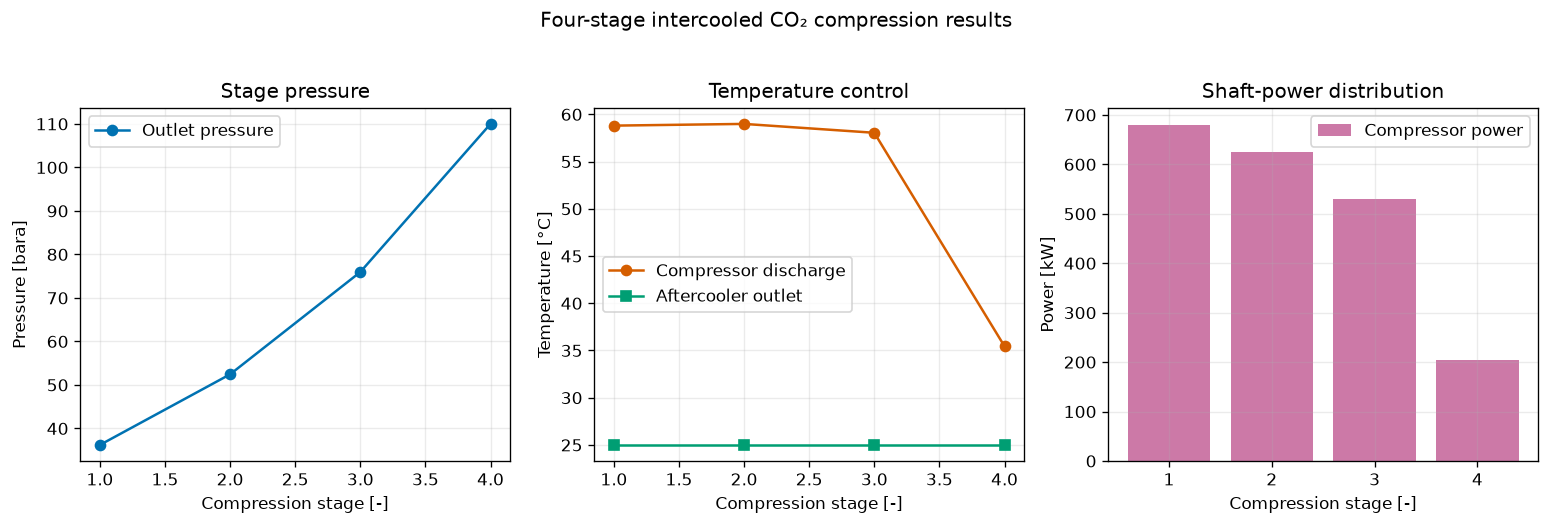

In [12]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(13.0, 4.2),
)
stage_numbers = stage_table["Stage [-]"]

axes[0].plot(
    stage_numbers,
    stage_table["Outlet pressure [bara]"],
    marker="o",
    color=BLUE,
    label="Outlet pressure",
)
axes[0].set_title("Stage pressure")
axes[0].set_xlabel("Compression stage [-]")
axes[0].set_ylabel("Pressure [bara]")
axes[0].legend()

axes[1].plot(
    stage_numbers,
    stage_table["Discharge temperature [°C]"],
    marker="o",
    color=ORANGE,
    label="Compressor discharge",
)
axes[1].plot(
    stage_numbers,
    stage_table["Aftercooler temperature [°C]"],
    marker="s",
    color=GREEN,
    label="Aftercooler outlet",
)
axes[1].set_title("Temperature control")
axes[1].set_xlabel("Compression stage [-]")
axes[1].set_ylabel("Temperature [°C]")
axes[1].legend()

axes[2].bar(
    stage_numbers,
    stage_table["Power [kW]"],
    color=PURPLE,
    label="Compressor power",
)
axes[2].set_title("Shaft-power distribution")
axes[2].set_xlabel("Compression stage [-]")
axes[2].set_ylabel("Power [kW]")
axes[2].legend()

figure.suptitle(
    "Four-stage intercooled CO₂ compression results",
    y=1.03,
)
plt.tight_layout()
plt.show()

The pressure ratio is nearly uniform, every aftercooler returns to 25 °C, and
the power distribution changes as density rises. The compressor and cooler
residuals in the table are reconstructed directly from NeqSim enthalpy rates;
they should remain near numerical zero.

In [13]:
multistage_power_kw = stage_table["Power [kW]"].sum()
direct_pr_power_kw = direct_pr_case[
    "compressor"
].getPower("kW")
legacy_srk_power_kw = legacy_srk_case[
    "compressor"
].getPower("kW")
staging_power_reduction_percent = (
    100.0
    * (direct_pr_power_kw - multistage_power_kw)
    / direct_pr_power_kw
)

strategy_table = pd.DataFrame(
    [
        {
            "Strategy": "Legacy SRK direct compression",
            "Power [kW]": legacy_srk_power_kw,
            "Maximum discharge temperature [°C]": (
                legacy_srk_case[
                    "compressor"
                ].getOutletStream().getTemperature("C")
            ),
        },
        {
            "Strategy": "PR direct compression",
            "Power [kW]": direct_pr_power_kw,
            "Maximum discharge temperature [°C]": (
                direct_pr_case[
                    "compressor"
                ].getOutletStream().getTemperature("C")
            ),
        },
        {
            "Strategy": "PR four-stage intercooling",
            "Power [kW]": multistage_power_kw,
            "Maximum discharge temperature [°C]": (
                stage_table[
                    "Discharge temperature [°C]"
                ].max()
            ),
        },
    ]
)
display(strategy_table)
print(
    "PR staging power reduction: "
    f"{staging_power_reduction_percent:.6f} %"
)

PR staging power reduction: 34.412049 %


,Strategy,Power [kW],Maximum discharge temperature [°C]
0,Legacy SRK direct compression,3183.178246,171.812956
1,PR direct compression,3110.052914,171.928998
2,PR four-stage intercooling,2039.819991,58.989098


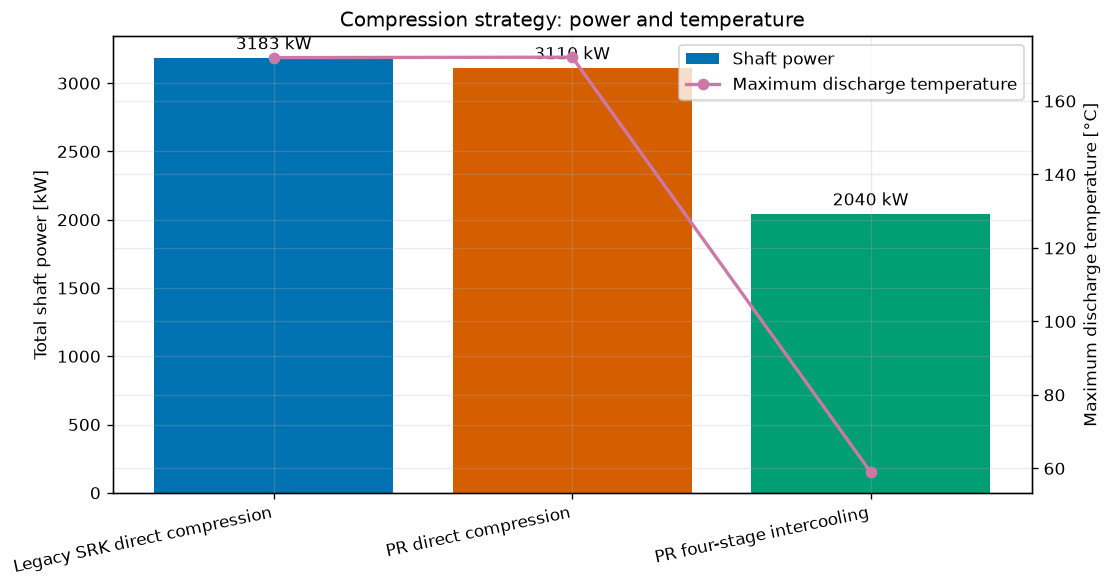

In [14]:
figure, power_axis = plt.subplots(
    figsize=(9.4, 5.0)
)
strategy_positions = np.arange(
    len(strategy_table)
)
power_bars = power_axis.bar(
    strategy_positions,
    strategy_table["Power [kW]"],
    color=[BLUE, ORANGE, GREEN],
    label="Shaft power",
)
power_axis.set_ylabel("Total shaft power [kW]")
power_axis.set_xticks(strategy_positions)
power_axis.set_xticklabels(
    strategy_table["Strategy"],
    rotation=12,
    ha="right",
)
power_axis.bar_label(
    power_bars,
    fmt="%.0f kW",
    padding=3,
)

temperature_axis = power_axis.twinx()
temperature_axis.plot(
    strategy_positions,
    strategy_table[
        "Maximum discharge temperature [°C]"
    ],
    color=PURPLE,
    marker="o",
    linewidth=2.0,
    label="Maximum discharge temperature",
)
temperature_axis.set_ylabel(
    "Maximum discharge temperature [°C]"
)

handles_1, labels_1 = (
    power_axis.get_legend_handles_labels()
)
handles_2, labels_2 = (
    temperature_axis.get_legend_handles_labels()
)
power_axis.legend(
    handles_1 + handles_2,
    labels_1 + labels_2,
    loc="upper right",
)
power_axis.set_title(
    "Compression strategy: power and temperature"
)
plt.tight_layout()
plt.show()

## 7. Pipeline calculation and profile retrieval

`PipeBeggsAndBrills` divides the 80 km line into 40 increments and solves
pressure loss with updated fluid properties. For this horizontal, isothermal,
single-phase base case, the dominant independent comparison is Darcy–Weisbach:

$$
\Delta p = f_D \frac{L}{D}\frac{\rho v^2}{2}
$$

and

$$
\mathrm{Re} = \frac{\rho vD}{\mu}
$$

Here $f_D$ is Darcy friction factor [-], $L$ is length [m], $D$ is inside
diameter [m], $\rho$ is density [kg/m³], $v$ is velocity [m/s], and $\mu$ is
dynamic viscosity [Pa·s]. Beggs–Brill is more general than this analytical
single-phase screen, but its original correlation range must be reviewed before
applying it to two-phase CO₂.

In [15]:
pipeline = integrated_chain["pipeline"]
pipeline_outlet = pipeline.getOutletStream()
pipeline_outlet_fluid = pipeline_outlet.getFluid()
pipeline_outlet_fluid.initProperties()

pressure_profile_bara = np.asarray(
    list(pipeline.getPressureProfile()),
    dtype=float,
)
density_profile_kg_per_m3 = np.asarray(
    list(pipeline.getMixtureDensityProfile()),
    dtype=float,
)
velocity_profile_m_per_s = np.asarray(
    list(
        pipeline.getMixtureSuperficialVelocityProfile()
    ),
    dtype=float,
)
reynolds_profile = np.asarray(
    list(pipeline.getMixtureReynoldsNumber()),
    dtype=float,
)
distance_profile_km = np.linspace(
    0.0,
    pipeline_length_m / 1000.0,
    pressure_profile_bara.size,
)

pipeline_summary = pd.DataFrame(
    [
        {
            "Quantity": "Inlet pressure",
            "Value": pressure_profile_bara[0],
            "Unit": "bara",
        },
        {
            "Quantity": "Arrival pressure",
            "Value": pressure_profile_bara[-1],
            "Unit": "bara",
        },
        {
            "Quantity": "Pressure drop",
            "Value": pipeline.getPressureDrop(),
            "Unit": "bar",
        },
        {
            "Quantity": "Outlet density",
            "Value": pipeline_outlet_fluid.getDensity(
                "kg/m3"
            ),
            "Unit": "kg/m³",
        },
        {
            "Quantity": "Maximum velocity",
            "Value": velocity_profile_m_per_s.max(),
            "Unit": "m/s",
        },
        {
            "Quantity": "Flow regime",
            "Value": pipeline.getFlowRegime(),
            "Unit": "-",
        },
    ]
)
display(pipeline_summary)

,Quantity,Value,Unit
0,Inlet pressure,110.0,bara
1,Arrival pressure,106.690111,bara
2,Pressure drop,3.309889,bar
3,Outlet density,701.84159,kg/m³
4,Maximum velocity,0.55992,m/s
5,Flow regime,"(S, I, N, G, L, E, _, P, H, A, S, E)",-


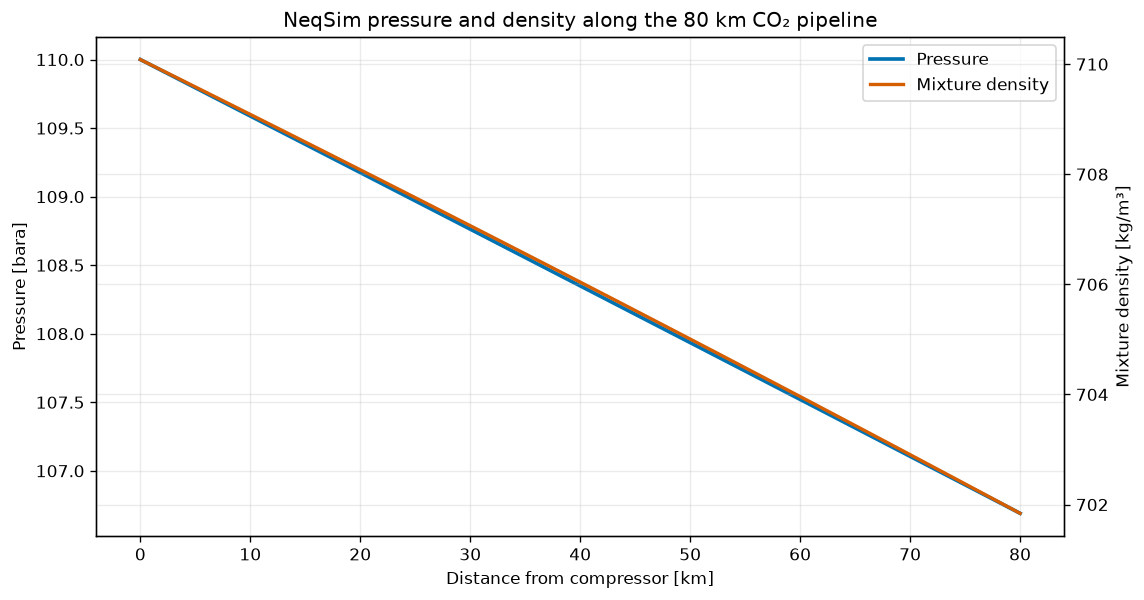

In [16]:
figure, pressure_axis = plt.subplots(
    figsize=(9.6, 5.1)
)
pressure_axis.plot(
    distance_profile_km,
    pressure_profile_bara,
    color=BLUE,
    linewidth=2.2,
    label="Pressure",
)
pressure_axis.set_xlabel("Distance from compressor [km]")
pressure_axis.set_ylabel("Pressure [bara]")

density_axis = pressure_axis.twinx()
density_axis.plot(
    distance_profile_km,
    density_profile_kg_per_m3,
    color=ORANGE,
    linewidth=2.0,
    label="Mixture density",
)
density_axis.set_ylabel("Mixture density [kg/m³]")

handles_1, labels_1 = (
    pressure_axis.get_legend_handles_labels()
)
handles_2, labels_2 = (
    density_axis.get_legend_handles_labels()
)
pressure_axis.legend(
    handles_1 + handles_2,
    labels_1 + labels_2,
    loc="best",
)
pressure_axis.set_title(
    "NeqSim pressure and density along the 80 km CO₂ pipeline"
)
plt.tight_layout()
plt.show()

Pressure and density both decrease smoothly toward the receiving terminal. The
stream remains single-phase and dense in this base case. The profile is more
informative than the original constant-gradient estimate because NeqSim updates
real-fluid density and viscosity along the line.

In [17]:
mean_density_kg_per_m3 = (
    density_profile_kg_per_m3.mean()
)
mean_velocity_m_per_s = (
    velocity_profile_m_per_s.mean()
)
mean_reynolds_number = reynolds_profile.mean()
relative_roughness = (
    pipe_roughness_m / pipeline_diameter_m
)
haaland_term = (
    (relative_roughness / 3.7) ** 1.11
    + 6.9 / mean_reynolds_number
)
darcy_friction_factor = (
    -1.8 * math.log10(haaland_term)
) ** -2
darcy_pressure_drop_pa = (
    darcy_friction_factor
    * pipeline_length_m
    / pipeline_diameter_m
    * mean_density_kg_per_m3
    * mean_velocity_m_per_s**2
    / 2.0
)
darcy_pressure_drop_bar = (
    darcy_pressure_drop_pa / 1.0e5
)
neqsim_pressure_drop_bar = (
    pressure_profile_bara[0]
    - pressure_profile_bara[-1]
)
pressure_drop_deviation_percent = (
    100.0
    * (
        neqsim_pressure_drop_bar
        - darcy_pressure_drop_bar
    )
    / darcy_pressure_drop_bar
)

hydraulic_validation = pd.DataFrame(
    [
        {
            "Method": "NeqSim PipeBeggsAndBrills",
            "Pressure drop [bar]": (
                neqsim_pressure_drop_bar
            ),
        },
        {
            "Method": "Independent Darcy–Haaland",
            "Pressure drop [bar]": (
                darcy_pressure_drop_bar
            ),
        },
        {
            "Method": "Legacy 0.08 bar/km",
            "Pressure drop [bar]": (
                0.08 * pipeline_length_m / 1000.0
            ),
        },
    ]
)
display(hydraulic_validation)
print(
    "NeqSim versus Darcy deviation: "
    f"{pressure_drop_deviation_percent:.6f} %"
)

NeqSim versus Darcy deviation: -0.073908 %


,Method,Pressure drop [bar]
0,NeqSim PipeBeggsAndBrills,3.309889
1,Independent Darcy–Haaland,3.312337
2,Legacy 0.08 bar/km,6.400000


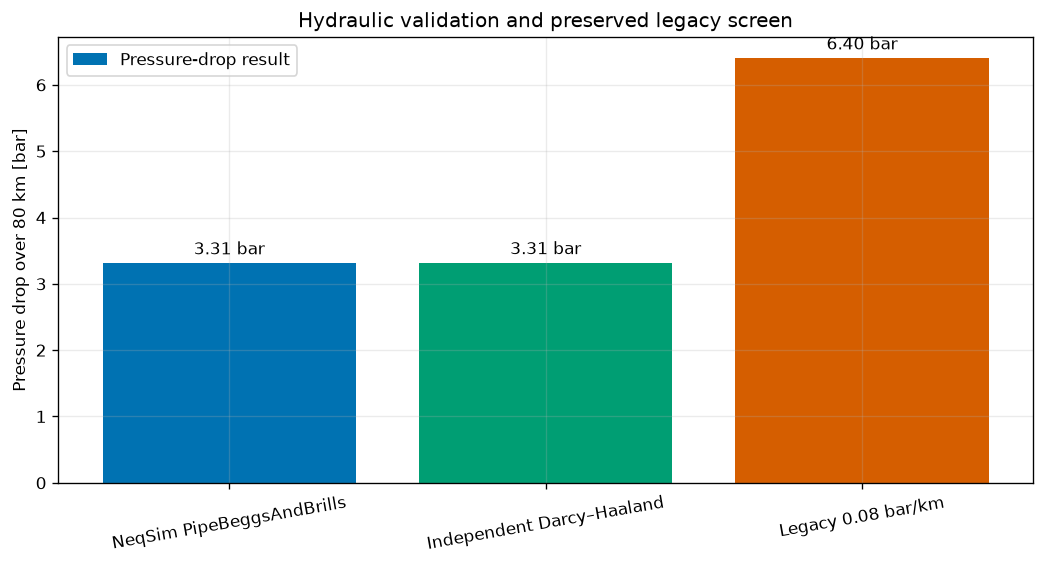

In [18]:
figure, axis = plt.subplots(
    figsize=(8.8, 4.8)
)
bars = axis.bar(
    hydraulic_validation["Method"],
    hydraulic_validation["Pressure drop [bar]"],
    color=[BLUE, GREEN, ORANGE],
    label="Pressure-drop result",
)
axis.bar_label(
    bars,
    fmt="%.2f bar",
    padding=3,
)
axis.set_ylabel("Pressure drop over 80 km [bar]")
axis.set_title(
    "Hydraulic validation and preserved legacy screen"
)
axis.tick_params(
    axis="x",
    rotation=10,
)
axis.legend()
plt.tight_layout()
plt.show()

The independent Darcy–Haaland result provides evidence level 2: comparison
against a separate analytical calculation. The legacy 6.4 bar estimate is
intentionally preserved, but it is conservative for this base case and cannot
respond to diameter, flow, or fluid-property changes.

## 8. CO₂-specific diagnostics and phase-density map

NeqSim's `CO2FlowCorrections` identifies CO₂-dominated fluids and returns a
correction factor intended for CO₂ flow-correlation work. Its `isDensePhase`
method checks a supercritical criterion based on pure-CO₂ critical constants.
At 25 °C the base stream is below pure CO₂ critical temperature, so that flag
is false even though the calculated liquid-like density exceeds 700 kg/m³.

Therefore the notebook reports three separate facts: phase count, density, and
supercritical flag. It does not use one ambiguous Boolean as a design verdict.

In [19]:
conditioned_fluid = (
    integrated_chain["coolers"][-1]
    .getOutletStream()
    .getFluid()
)
conditioned_fluid.initProperties()

co2_diagnostics = pd.DataFrame(
    [
        {
            "Diagnostic": "CO2-dominated fluid",
            "Value": CO2FlowCorrections.isCO2DominatedFluid(
                conditioned_fluid
            ),
            "Unit": "-",
        },
        {
            "Diagnostic": "CO2 mole fraction",
            "Value": CO2FlowCorrections.getCO2MoleFraction(
                conditioned_fluid
            ),
            "Unit": "mol/mol",
        },
        {
            "Diagnostic": "Friction correction factor",
            "Value": (
                CO2FlowCorrections
                .getFrictionCorrectionFactor(
                    conditioned_fluid
                )
            ),
            "Unit": "-",
        },
        {
            "Diagnostic": "Supercritical flag",
            "Value": CO2FlowCorrections.isDensePhase(
                conditioned_fluid
            ),
            "Unit": "-",
        },
        {
            "Diagnostic": "Calculated density",
            "Value": conditioned_fluid.getDensity(
                "kg/m3"
            ),
            "Unit": "kg/m³",
        },
        {
            "Diagnostic": "Calculated phase count",
            "Value": conditioned_fluid.getNumberOfPhases(),
            "Unit": "-",
        },
    ]
)
display(co2_diagnostics)

,Diagnostic,Value,Unit
0,CO2-dominated fluid,True,-
1,CO2 mole fraction,0.96,mol/mol
2,Friction correction factor,0.85,-
3,Supercritical flag,False,-
4,Calculated density,710.083512,kg/m³
5,Calculated phase count,1,-


In [20]:
map_temperatures_c = np.array(
    [15.0, 25.0, 35.0, 45.0, 55.0]
)
map_pressures_bara = np.array(
    [60.0, 70.0, 80.0, 90.0, 100.0, 110.0, 120.0]
)
density_map = np.zeros(
    (
        map_temperatures_c.size,
        map_pressures_bara.size,
    )
)
phase_count_map = np.zeros_like(
    density_map,
    dtype=int,
)

for temperature_index, temperature_c in enumerate(
    map_temperatures_c
):
    for pressure_index, pressure_bara in enumerate(
        map_pressures_bara
    ):
        map_fluid = make_co2_fluid(
            temperature_c,
            pressure_bara,
            "pr",
        )
        density_map[
            temperature_index,
            pressure_index,
        ] = map_fluid.getDensity("kg/m3")
        phase_count_map[
            temperature_index,
            pressure_index,
        ] = map_fluid.getNumberOfPhases()

map_summary = pd.DataFrame(
    {
        "Temperature [°C]": np.repeat(
            map_temperatures_c,
            map_pressures_bara.size,
        ),
        "Pressure [bara]": np.tile(
            map_pressures_bara,
            map_temperatures_c.size,
        ),
        "Density [kg/m³]": density_map.ravel(),
        "Phases [-]": phase_count_map.ravel(),
    }
)
display(map_summary.head(10))

,Temperature [°C],Pressure [bara],Density [kg/m³],Phases [-]
0,15.0,60.0,528.236032,2
1,15.0,70.0,715.892744,1
2,15.0,80.0,742.918571,1
3,15.0,90.0,764.637805,1
4,15.0,100.0,782.989432,1
5,15.0,110.0,798.977516,1
6,15.0,120.0,813.198577,1
7,25.0,60.0,175.671025,1
8,25.0,70.0,280.808055,2
9,25.0,80.0,595.427883,1


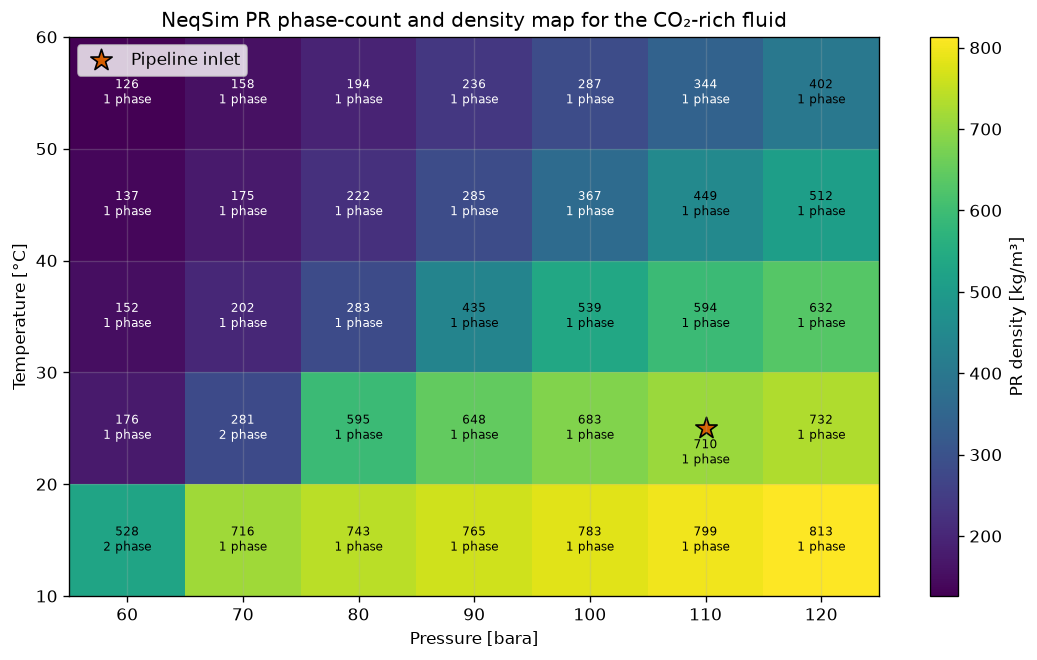

In [21]:
figure, axis = plt.subplots(
    figsize=(9.2, 5.6)
)
image = axis.imshow(
    density_map,
    origin="lower",
    aspect="auto",
    cmap="viridis",
    extent=[
        map_pressures_bara.min() - 5.0,
        map_pressures_bara.max() + 5.0,
        map_temperatures_c.min() - 5.0,
        map_temperatures_c.max() + 5.0,
    ],
)
colorbar = figure.colorbar(
    image,
    ax=axis,
)
colorbar.set_label("PR density [kg/m³]")

for temperature_index, temperature_c in enumerate(
    map_temperatures_c
):
    for pressure_index, pressure_bara in enumerate(
        map_pressures_bara
    ):
        annotation_temperature_c = temperature_c
        is_pipeline_inlet_cell = (
            pressure_bara == pipeline_inlet_pressure_bara
            and temperature_c == intercooler_temperature_c
        )
        if is_pipeline_inlet_cell:
            annotation_temperature_c -= 2.2

        axis.text(
            pressure_bara,
            annotation_temperature_c,
            (
                f"{density_map[temperature_index, pressure_index]:.0f}\n"
                f"{phase_count_map[temperature_index, pressure_index]} phase"
            ),
            ha="center",
            va="center",
            color="white"
            if density_map[
                temperature_index,
                pressure_index,
            ] < 400.0
            else "black",
            fontsize=7,
        )

axis.scatter(
    [pipeline_inlet_pressure_bara],
    [intercooler_temperature_c],
    marker="*",
    s=180,
    color=ORANGE,
    edgecolor="black",
    label="Pipeline inlet",
)
axis.set_xlabel("Pressure [bara]")
axis.set_ylabel("Temperature [°C]")
axis.set_title(
    "NeqSim PR phase-count and density map for the CO₂-rich fluid"
)
axis.legend(loc="upper left")
plt.tight_layout()
plt.show()

The map makes the operating-window issue explicit: density changes sharply
across pressure and temperature, and some points may enter two-phase behavior.
A project phase envelope and impurity uncertainty study are mandatory before
setting operating limits.

## 9. Diameter and throughput design study

The reusable function below initializes a fresh PR fluid and a fresh pipe for
each case. Feasibility requires arrival pressure at least 90 bara and maximum
mixture superficial velocity no more than 2.0 m/s:

$$
M_p = p_{\mathrm{arrival}} - p_{\mathrm{minimum}}
$$

Positive $M_p$ indicates pressure margin. The velocity criterion is an
educational operability screen, not a standard-based design limit.

In [22]:
def run_pipeline_case(
    flow_rate_kg_per_h,
    diameter_m,
):
    fluid = make_co2_fluid(
        intercooler_temperature_c,
        pipeline_inlet_pressure_bara,
        "pr",
    )
    feed = Stream("Pipeline scenario feed", fluid)
    feed.setFlowRate(
        flow_rate_kg_per_h,
        "kg/hr",
    )
    pipe = PipeBeggsAndBrills(
        "Pipeline scenario",
        feed,
    )
    pipe.setLength(pipeline_length_m)
    pipe.setElevation(0.0)
    pipe.setDiameter(diameter_m)
    pipe.setPipeWallRoughness(pipe_roughness_m)
    pipe.setNumberOfIncrements(
        pipeline_increments
    )
    pipe.setRunIsothermal(True)
    process = ProcessSystem()
    process.add(feed)
    process.add(pipe)
    process.run()

    outlet_fluid = pipe.getOutletStream().getFluid()
    outlet_fluid.initProperties()
    velocity_profile = np.asarray(
        list(
            pipe.getMixtureSuperficialVelocityProfile()
        ),
        dtype=float,
    )
    arrival_pressure_bara = (
        pipe.getOutletStream().getPressure("bara")
    )
    maximum_velocity = velocity_profile.max()
    pressure_margin_bara = (
        arrival_pressure_bara
        - minimum_arrival_pressure_bara
    )
    feasible = (
        pressure_margin_bara >= 0.0
        and maximum_velocity
        <= maximum_velocity_m_per_s
        and outlet_fluid.getNumberOfPhases() == 1
        and outlet_fluid.getDensity("kg/m3") > 400.0
    )
    return {
        "Flow [kg/h]": flow_rate_kg_per_h,
        "Diameter [m]": diameter_m,
        "Arrival pressure [bara]": (
            arrival_pressure_bara
        ),
        "Pressure margin [bar]": (
            pressure_margin_bara
        ),
        "Maximum velocity [m/s]": maximum_velocity,
        "Outlet density [kg/m³]": (
            outlet_fluid.getDensity("kg/m3")
        ),
        "Outlet phases [-]": (
            outlet_fluid.getNumberOfPhases()
        ),
        "Feasible [-]": feasible,
    }

In [23]:
design_flow_rates = [
    75000.0,
    100000.0,
    125000.0,
]
design_diameters = [
    0.20,
    0.25,
    0.30,
    0.35,
]
design_rows = []

for flow_rate_kg_per_h in design_flow_rates:
    for diameter_m in design_diameters:
        design_rows.append(
            run_pipeline_case(
                flow_rate_kg_per_h,
                diameter_m,
            )
        )

design_table = pd.DataFrame(design_rows)
display(design_table)

,Flow [kg/h],Diameter [m],Arrival pressure [bara],Pressure margin [bar],Maximum velocity [m/s],Outlet density [kg/m³],Outlet phases [-],Feasible [-]
0,75000.0,0.20,95.201439,5.201439,0.992938,667.861739,1,True
1,75000.0,0.25,105.241786,15.241786,0.607994,698.054533,1,True
2,75000.0,0.30,108.085057,18.085057,0.417832,705.382052,1,True
3,75000.0,0.35,109.107067,19.107067,0.305881,707.913262,1,True
4,100000.0,0.20,83.513924,-6.486076,1.431872,617.509193,1,False
5,100000.0,0.25,101.707094,11.707094,0.822168,688.283197,1,True
6,100000.0,0.30,106.690111,16.690111,0.559920,701.841590,1,True
7,100000.0,0.35,108.464009,18.464009,0.408758,706.326621,1,True
8,125000.0,0.20,58.518978,-31.481022,6.621524,166.916651,1,False
9,125000.0,0.25,97.160039,7.160039,1.048868,674.398635,1,True


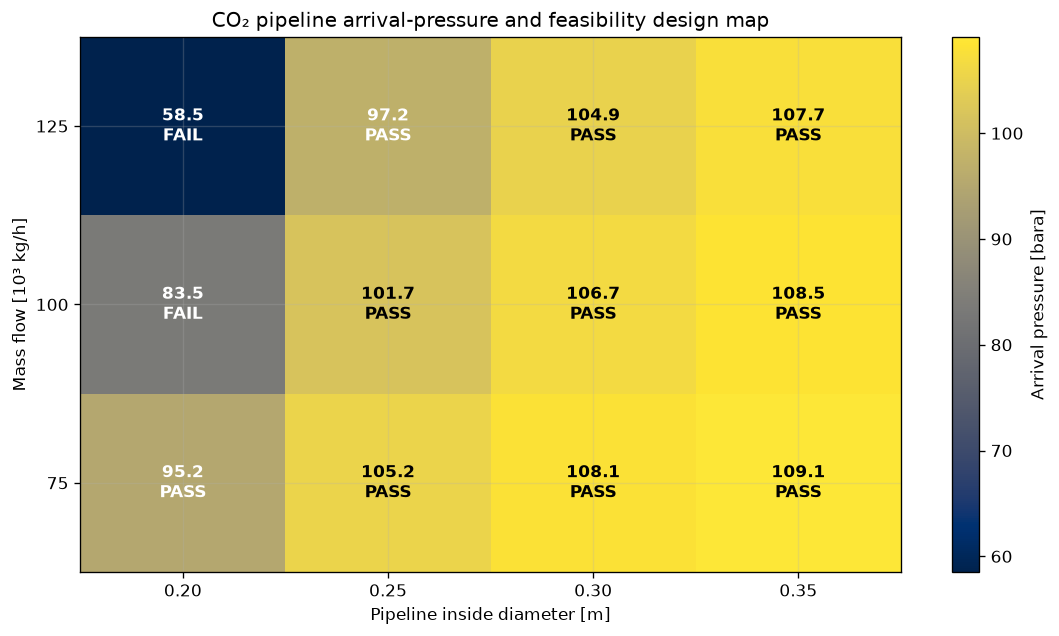

In [24]:
pressure_pivot = design_table.pivot(
    index="Flow [kg/h]",
    columns="Diameter [m]",
    values="Arrival pressure [bara]",
)
feasible_pivot = design_table.pivot(
    index="Flow [kg/h]",
    columns="Diameter [m]",
    values="Feasible [-]",
)

figure, axis = plt.subplots(
    figsize=(9.4, 5.4)
)
image = axis.imshow(
    pressure_pivot.to_numpy(),
    origin="lower",
    aspect="auto",
    cmap="cividis",
)
colorbar = figure.colorbar(
    image,
    ax=axis,
)
colorbar.set_label("Arrival pressure [bara]")
axis.set_xticks(
    np.arange(len(pressure_pivot.columns))
)
axis.set_xticklabels(
    [
        f"{diameter:.2f}"
        for diameter in pressure_pivot.columns
    ]
)
axis.set_yticks(
    np.arange(len(pressure_pivot.index))
)
axis.set_yticklabels(
    [
        f"{flow_rate / 1000.0:.0f}"
        for flow_rate in pressure_pivot.index
    ]
)

for row_index in range(
    pressure_pivot.shape[0]
):
    for column_index in range(
        pressure_pivot.shape[1]
    ):
        arrival_pressure = pressure_pivot.iloc[
            row_index,
            column_index,
        ]
        feasible = feasible_pivot.iloc[
            row_index,
            column_index,
        ]
        axis.text(
            column_index,
            row_index,
            (
                f"{arrival_pressure:.1f}\n"
                f"{'PASS' if feasible else 'FAIL'}"
            ),
            ha="center",
            va="center",
            color="white"
            if arrival_pressure < 100.0
            else "black",
            weight="bold",
        )

axis.set_xlabel("Pipeline inside diameter [m]")
axis.set_ylabel("Mass flow [10³ kg/h]")
axis.set_title(
    "CO₂ pipeline arrival-pressure and feasibility design map"
)
plt.tight_layout()
plt.show()

The design map shows the nonlinear diameter effect. The 0.20 m line passes at
75,000 kg/h but fails the 90 bara arrival criterion at higher flow. Increasing
diameter reduces velocity and friction loss, creating capacity margin.

## 10. Practical application: select and rerun a target design

For a target of 125,000 kg/h, the notebook selects the smallest feasible
diameter from the tested set. It reruns that case independently, rather than
trusting a row that may depend on earlier mutable state.

In [25]:
target_flow_kg_per_h = 125000.0
target_candidates = design_table[
    (
        design_table["Flow [kg/h]"]
        == target_flow_kg_per_h
    )
    & design_table["Feasible [-]"]
].sort_values("Diameter [m]")

selected_design = target_candidates.iloc[0]
selected_rerun = run_pipeline_case(
    target_flow_kg_per_h,
    float(selected_design["Diameter [m]"]),
)

selected_table = pd.DataFrame(
    [selected_rerun]
)
display(selected_table)

,Flow [kg/h],Diameter [m],Arrival pressure [bara],Pressure margin [bar],Maximum velocity [m/s],Outlet density [kg/m³],Outlet phases [-],Feasible [-]
0,125000.0,0.25,97.160039,7.160039,1.048868,674.398635,1,True


The selected diameter is the smallest tested design satisfying all four
educational constraints: arrival pressure, velocity, one-phase operation, and
density above the preserved 400 kg/m³ screen. Mechanical design, fracture
control, decompression behavior, impurity limits, corrosion, availability,
terrain, and lifecycle economics remain outside this selection.

In [26]:
feed_mass_flow_kg_per_h = integrated_chain[
    "feed"
].getFlowRate("kg/hr")
pipeline_mass_flow_kg_per_h = (
    pipeline.getOutletStream().getFlowRate("kg/hr")
)
mass_residual_kg_per_h = (
    pipeline_mass_flow_kg_per_h
    - feed_mass_flow_kg_per_h
)
inlet_co2_fraction = (
    integrated_chain["feed"]
    .getFluid()
    .getComponent("CO2")
    .getz()
)
outlet_co2_fraction = (
    pipeline.getOutletStream()
    .getFluid()
    .getComponent("CO2")
    .getz()
)
component_residual = (
    outlet_co2_fraction - inlet_co2_fraction
)
maximum_compressor_residual_w = (
    stage_table[
        "Compressor residual [W]"
    ].abs().max()
)
maximum_cooler_residual_w = (
    stage_table[
        "Cooler residual [W]"
    ].abs().max()
)

report = {
    "schema_version": "1.0",
    "neqsim_version": importlib.metadata.version(
        "neqsim"
    ),
    "fluid": {
        "composition_mol_fraction": composition,
        "thermodynamic_model": "Peng-Robinson",
    },
    "compression": {
        "stages": number_of_stages,
        "total_power_kW": multistage_power_kw,
        "direct_PR_power_kW": direct_pr_power_kw,
        "staging_power_reduction_percent": (
            staging_power_reduction_percent
        ),
    },
    "base_pipeline": {
        "length_km": pipeline_length_m / 1000.0,
        "diameter_m": pipeline_diameter_m,
        "arrival_pressure_bara": (
            pressure_profile_bara[-1]
        ),
        "pressure_drop_bar": (
            neqsim_pressure_drop_bar
        ),
        "maximum_velocity_m_per_s": (
            velocity_profile_m_per_s.max()
        ),
        "outlet_density_kg_per_m3": (
            pipeline_outlet_fluid.getDensity("kg/m3")
        ),
    },
    "selected_design": selected_rerun,
    "balances": {
        "mass_residual_kg_per_h": (
            mass_residual_kg_per_h
        ),
        "CO2_fraction_residual": component_residual,
        "maximum_compressor_residual_W": (
            maximum_compressor_residual_w
        ),
        "maximum_cooler_residual_W": (
            maximum_cooler_residual_w
        ),
    },
    "limitations": (
        "Steady-state educational screen; add validated "
        "phase behavior, heat transfer, terrain, transient "
        "decompression, fracture control, corrosion, and "
        "mechanical design before project decisions."
    ),
}
print(json.dumps(report, indent=2))

{
  "schema_version": "1.0",
  "neqsim_version": "3.16.0",
  "fluid": {
    "composition_mol_fraction": {
      "CO2": 0.96,
      "methane": 0.03,
      "nitrogen": 0.01
    },
    "thermodynamic_model": "Peng-Robinson"
  },
  "compression": {
    "stages": 4,
    "total_power_kW": 2039.8199912721539,
    "direct_PR_power_kW": 3110.0529137386634,
    "staging_power_reduction_percent": 34.41204867411593
  },
  "base_pipeline": {
    "length_km": 80.0,
    "diameter_m": 0.3,
    "arrival_pressure_bara": 106.69011085699428,
    "pressure_drop_bar": 3.3098891430057193,
    "maximum_velocity_m_per_s": 0.5599200356169599,
    "outlet_density_kg_per_m3": 701.8415901033593
  },
  "selected_design": {
    "Flow [kg/h]": 125000.0,
    "Diameter [m]": 0.25,
    "Arrival pressure [bara]": 97.16003915568915,
    "Pressure margin [bar]": 7.160039155689148,
    "Maximum velocity [m/s]": 1.0488682298368137,
    "Outlet density [kg/m\u00b3]": 674.3986351275971,
    "Outlet phases [-]": 1,
    "Feasibl

## 11. Verification checks

The assertions cover normalized inputs, model behavior, staging, process
connectivity, energy-rate reconstruction, pipeline profiles, mass and component
closure, independent pressure-drop agreement, scenario trends, and deterministic
design rerun. These checks are focused engineering evidence—not certification.

In [27]:
selected_original_row = target_candidates.iloc[0]
selected_arrival_difference = abs(
    selected_rerun["Arrival pressure [bara]"]
    - selected_original_row[
        "Arrival pressure [bara]"
    ]
)
selected_velocity_difference = abs(
    selected_rerun["Maximum velocity [m/s]"]
    - selected_original_row[
        "Maximum velocity [m/s]"
    ]
)
diameter_trend_table = design_table[
    design_table["Flow [kg/h]"]
    == mass_flow_kg_per_h
].sort_values("Diameter [m]")
flow_trend_table = design_table[
    design_table["Diameter [m]"]
    == pipeline_diameter_m
].sort_values("Flow [kg/h]")

checks = {
    "composition normalized": (
        abs(composition_sum - 1.0) < 1.0e-12
    ),
    "legacy composition preserved": (
        composition
        == {
            "CO2": 0.96,
            "methane": 0.03,
            "nitrogen": 0.01,
        }
    ),
    "legacy flow preserved": (
        mass_flow_kg_per_h == 100000.0
    ),
    "legacy pressure endpoints preserved": (
        feed_pressure_bara == 25.0
        and pipeline_inlet_pressure_bara == 110.0
    ),
    "legacy aftercooler temperature preserved": (
        intercooler_temperature_c == 25.0
    ),
    "legacy pipeline length preserved": (
        pipeline_length_m == 80000.0
    ),
    "feed states finite": (
        np.isfinite(
            feed_state_table.select_dtypes(
                include=[float, int]
            ).to_numpy()
        ).all()
    ),
    "four compression stages": (
        len(stage_table) == number_of_stages
    ),
    "stage pressures increase": (
        np.diff(
            stage_table["Outlet pressure [bara]"]
        )
        > 0.0
    ).all(),
    "aftercoolers meet target": (
        np.allclose(
            stage_table[
                "Aftercooler temperature [°C]"
            ],
            intercooler_temperature_c,
            atol=1.0e-8,
        )
    ),
    "compressor powers positive": (
        stage_table["Power [kW]"] > 0.0
    ).all(),
    "compressor balances close": (
        maximum_compressor_residual_w < 1.0e-6
    ),
    "cooler balances close": (
        maximum_cooler_residual_w < 1.0e-6
    ),
    "staging reduces PR power": (
        multistage_power_kw < direct_pr_power_kw
    ),
    "staging reduces maximum temperature": (
        stage_table[
            "Discharge temperature [°C]"
        ].max()
        < direct_pr_case[
            "compressor"
        ].getOutletStream().getTemperature("C")
    ),
    "pipeline profile has 41 nodes": (
        pressure_profile_bara.size
        == pipeline_increments + 1
    ),
    "pipeline pressure decreases": (
        np.diff(pressure_profile_bara) < 0.0
    ).all(),
    "pipeline density decreases": (
        np.diff(density_profile_kg_per_m3) < 0.0
    ).all(),
    "pipeline velocity positive": (
        velocity_profile_m_per_s > 0.0
    ).all(),
    "pipeline Reynolds turbulent": (
        reynolds_profile > 4000.0
    ).all(),
    "base arrival pressure passes": (
        pressure_profile_bara[-1]
        >= minimum_arrival_pressure_bara
    ),
    "base velocity passes": (
        velocity_profile_m_per_s.max()
        <= maximum_velocity_m_per_s
    ),
    "base outlet remains one phase": (
        pipeline_outlet_fluid.getNumberOfPhases() == 1
    ),
    "base outlet remains dense": (
        pipeline_outlet_fluid.getDensity("kg/m3")
        > 400.0
    ),
    "mass balance closes": (
        abs(mass_residual_kg_per_h) < 1.0e-8
    ),
    "CO2 fraction closes": (
        abs(component_residual) < 1.0e-12
    ),
    "Darcy screen agrees within ten percent": (
        abs(pressure_drop_deviation_percent) < 10.0
    ),
    "CO2 utility recognizes composition": (
        CO2FlowCorrections.isCO2DominatedFluid(
            conditioned_fluid
        )
    ),
    "CO2 utility fraction matches input": (
        abs(
            CO2FlowCorrections.getCO2MoleFraction(
                conditioned_fluid
            )
            - composition["CO2"]
        )
        < 1.0e-12
    ),
    "state map finite": (
        np.isfinite(density_map).all()
    ),
    "state map density positive": (
        density_map > 0.0
    ).all(),
    "larger diameter raises arrival pressure": (
        np.diff(
            diameter_trend_table[
                "Arrival pressure [bara]"
            ]
        )
        > 0.0
    ).all(),
    "higher flow lowers arrival pressure": (
        np.diff(
            flow_trend_table[
                "Arrival pressure [bara]"
            ]
        )
        < 0.0
    ).all(),
    "selected design feasible": (
        bool(selected_rerun["Feasible [-]"])
    ),
    "selected diameter is 0.25 m": (
        abs(
            selected_rerun["Diameter [m]"] - 0.25
        )
        < 1.0e-12
    ),
    "selected rerun pressure deterministic": (
        selected_arrival_difference < 1.0e-10
    ),
    "selected rerun velocity deterministic": (
        selected_velocity_difference < 1.0e-10
    ),
}

failed_checks = [
    check_name
    for check_name, passed in checks.items()
    if not passed
]

assert not failed_checks, failed_checks
print(
    f"All {len(checks)} engineering checks passed."
)

All 37 engineering checks passed.


In [28]:
check_table = pd.DataFrame(
    [
        {
            "Check": check_name,
            "Passed": bool(passed),
        }
        for check_name, passed in checks.items()
    ]
)
display(check_table)

,Check,Passed
0,composition normalized,True
1,legacy composition preserved,True
2,legacy flow preserved,True
3,legacy pressure endpoints preserved,True
4,legacy aftercooler temperature preserved,True
5,legacy pipeline length preserved,True
6,feed states finite,True
7,four compression stages,True
8,stage pressures increase,True
9,aftercoolers meet target,True


## 12. Engineering interpretation

For this synthetic basis, four-stage PR compression cuts power materially
relative to the PR direct-compression baseline and holds stage discharge
temperatures below the single-stage result. The 0.30 m, 80 km base pipeline
retains substantial pressure and velocity margin at 100,000 kg/h. The design
map selects 0.25 m for 125,000 kg/h among the tested diameters.

Those conclusions are conditional on composition, model, isothermal operation,
roughness, level route, pressure criteria, and steady-state flow. They must not
be generalized to a project without updated inputs and validation.

## 13. Limitations and applicability

- PR and SRK are engineering cubic equations of state; validate phase behavior
  against high-quality CO₂-mixture data or a qualified reference model.
- Water and reactive impurities are omitted. The example does not assess
  corrosion, hydrate formation, free water, acids, or materials compatibility.
- The pipeline is horizontal and isothermal. Terrain, heat transfer, seabed
  temperature, start-up, shutdown, line packing, and transient decompression
  are outside scope.
- Beggs–Brill was developed for hydrocarbon multiphase flow. Its single-phase
  result is checked here, but two-phase CO₂ use needs dedicated validation.
- Diameter selection omits wall thickness, fracture control, running-ductile
  fracture, impurities, availability, CAPEX, OPEX, and standards compliance.

## 14. Troubleshooting

- If a flash fails near the critical region, move the initial state away from
  the phase boundary, verify units, and approach the target in smaller steps.
- If a pipeline case produces a very low arrival pressure, increase diameter,
  reduce flow, increase inlet pressure, or shorten the line before detailed
  solver tuning.
- If density or phase count looks surprising, inspect both rather than applying
  a density threshold alone.
- Always create fresh fluids and processes for sensitivity points; reused
  mutable states can make results order-dependent.
- A negative cooler duty means heat is removed under NeqSim's sign convention.

## 15. Summary and further exercises

This notebook preserved the original compact CO₂-chain example and converted it
into a connected NeqSim workflow with SRK/PR model visibility, direct and staged
compression, intercooling, pipeline hydraulics, profile retrieval, CO₂-specific
diagnostics, independent validation, design scenarios, and structured results.

**Exercises**

1. add water and investigate the separate dehydration and corrosion questions;
2. replace isothermal operation with an external-temperature profile;
3. add elevation and compare offshore and onshore routes;
4. sweep methane and nitrogen impurities and redraw the density map;
5. add a compressor-map constraint and an economic diameter objective; and
6. extend the receiving boundary into an injection-well model.

## 16. Authoritative references

- [NeqSim pipeline simulation guide](https://equinor.github.io/neqsim/process/equipment/pipeline_simulation.html)
- [NeqSim pipeline equipment documentation](https://equinor.github.io/neqsim/process/equipment/pipelines.html)
- [NeqSim phase-envelope guide](https://equinor.github.io/neqsim/pvtsimulation/phase_envelope_guide.html)
- [NeqSim CO₂ injection-well analysis](https://equinor.github.io/neqsim/process/co2_injection_well_analysis.html)
- [NeqSim process-simulation documentation](https://equinor.github.io/neqsim/process/)
- [Current public NeqSim package on PyPI](https://pypi.org/project/neqsim/)
- Beggs, H. D., and Brill, J. P. (1973), *A Study of Two-Phase Flow in
  Inclined Pipes*, Journal of Petroleum Technology, 25(5), 607–617.
- Haaland, S. E. (1983), *Simple and Explicit Formulas for the Friction
  Factor in Turbulent Pipe Flow*, Journal of Fluids Engineering, 105(1),
  89–90.